In [ ]:
import pandas as pd
columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
data = pd.read_csv('data_banknote_authentication.txt', header=None, names=columns)

data.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
print(data.shape)

(1372, 5)


In [ ]:
print(data.isnull().sum())

variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64


In [ ]:
data.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [ ]:
print("\nClass balance:\n", data['class'].value_counts())


Class balance:
 class
0    762
1    610
Name: count, dtype: int64


In [ ]:
#Now to plots

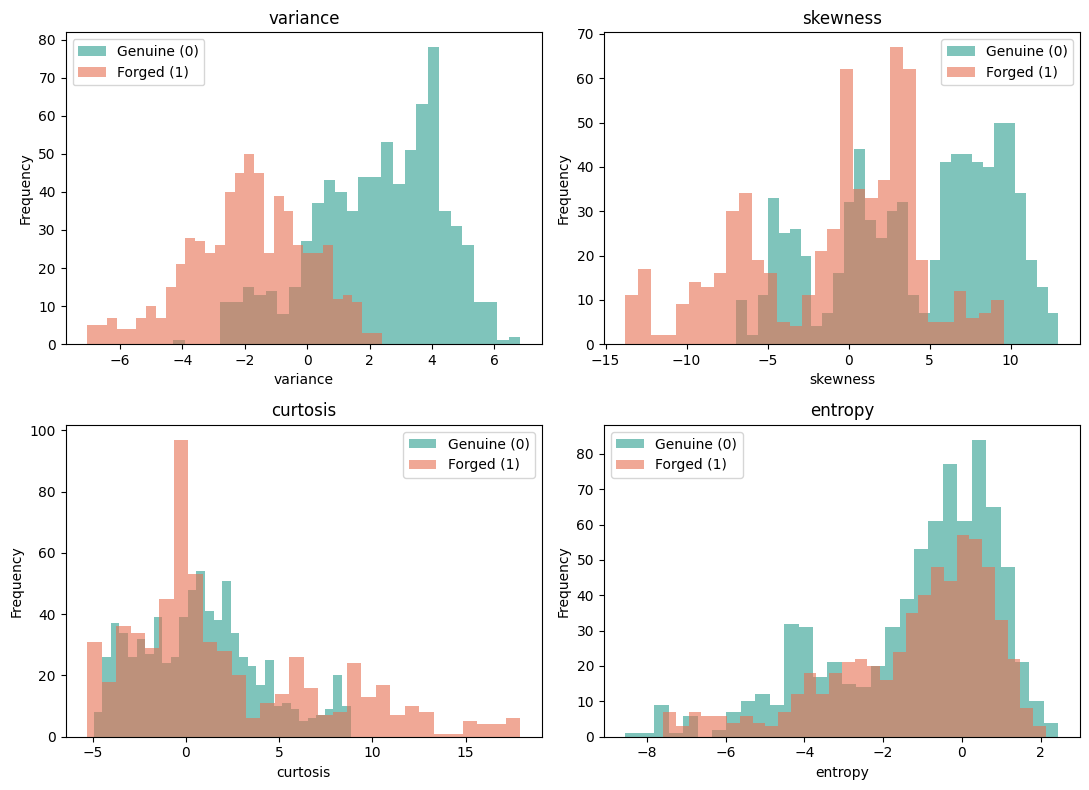

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
features = ['variance', 'skewness', 'curtosis', 'entropy']

for ax, feat in zip(axes.flatten(), features):

    ax.hist(data[data['class'] == 0][feat], bins=30, alpha=0.6,
             label='Genuine (0)', color='#2a9d8f')
    ax.hist(data[data['class'] == 1][feat], bins=30, alpha=0.6,
             label='Forged (1)', color='#e76f51')
    ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig('histograms.eps', dpi=600)
plt.show()

In [ ]:
corr = data.corr()
print(corr.round(3))


          variance  skewness  curtosis  entropy  class
variance     1.000     0.264    -0.381    0.277 -0.725
skewness     0.264     1.000    -0.787   -0.526 -0.445
curtosis    -0.381    -0.787     1.000    0.319  0.156
entropy      0.277    -0.526     0.319    1.000 -0.023
class       -0.725    -0.445     0.156   -0.023  1.000


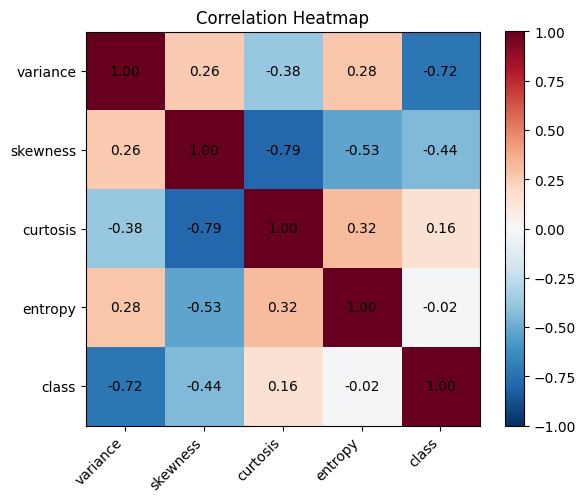

In [ ]:

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black')

plt.colorbar(im)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('heatmap.eps', dpi=600)
plt.show()

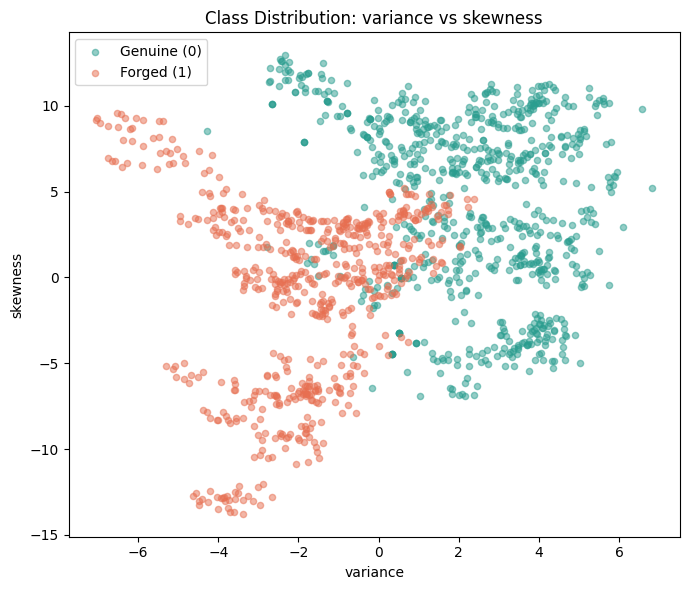

In [ ]:

fig, ax = plt.subplots(figsize=(7, 6))
genuine = data[data['class'] == 0]
forged = data[data['class'] == 1]

ax.scatter(genuine['variance'], genuine['skewness'], alpha=0.5,
           label='Genuine (0)', color='#2a9d8f', s=20)
ax.scatter(forged['variance'], forged['skewness'], alpha=0.5,
           label='Forged (1)', color='#e76f51', s=20)
ax.set_xlabel('variance')
ax.set_ylabel('skewness')
ax.set_title('Class Distribution: variance vs skewness')
ax.legend()
plt.tight_layout()
plt.savefig('scatter.eps', dpi=600)
plt.show()

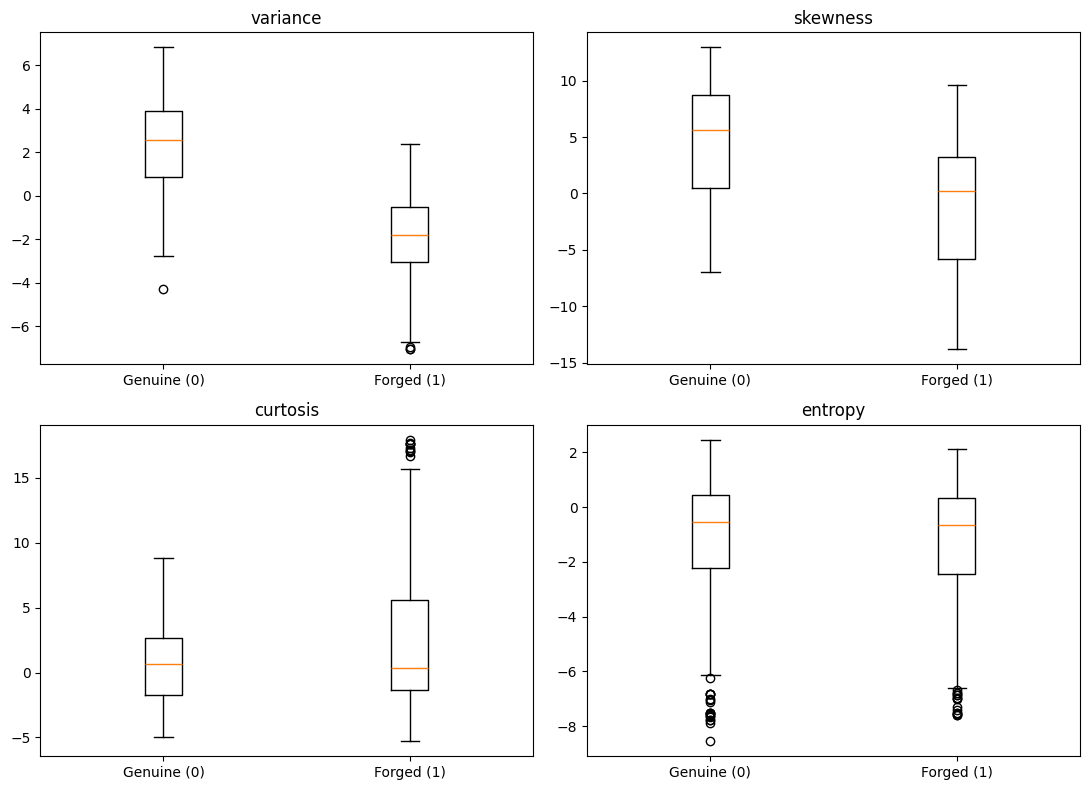

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
features = ['variance', 'skewness', 'curtosis', 'entropy']

for ax, feat in zip(axes.flatten(), features):
    data0 = data[data['class'] == 0][feat]
    data1 = data[data['class'] == 1][feat]
    ax.boxplot([data0, data1], tick_labels=['Genuine (0)', 'Forged (1)'])
    ax.set_title(feat)

plt.tight_layout()
plt.savefig('boxplots.eps', dpi=600)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X = data[['variance', 'skewness', 'curtosis', 'entropy']].values
y = data['class'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

Train shape: (1097, 4)
Test shape : (275, 4)


In [ ]:
import numpy as np
n_features = X_train_scaled.shape[1]
weights = np.zeros(n_features)
bias = 0.0

In [ ]:
def step_activation(z):
    return 1 if z >= 0 else 0

In [ ]:
def predict(x, weights, bias):
    z = np.dot(x, weights) + bias
    return step_activation(z)

In [ ]:
def train_perceptron(X, y, lr=0.01, epochs=50):
    n_features = X.shape[1]
    weights = np.zeros(n_features)
    bias = 0.0

    history = []
    for epoch in range(1, epochs + 1):
        misclassified = 0

        for i in range(len(X)):
            x_i = X[i]
            y_true = y[i]

            y_pred = predict(x_i, weights, bias)
            error = y_true - y_pred

            if error != 0:
                misclassified += 1
                weights = weights + lr * error * x_i
                bias = bias + lr * error

        history.append((epoch, misclassified, weights.copy(), bias))

        if misclassified == 0:
            print(f"Converged at epoch {epoch} (0 misclassifications)")
            break

    return weights, bias, history

In [ ]:


weights, bias, history = train_perceptron(X_train_scaled, y_train, lr=0.01, epochs=50)

print("Epoch | Misclassified | Weights                          | Bias")
for epoch, mis, w, b in history:
    print(f"{epoch:5d} | {mis:13d} | {np.round(w, 3)} | {b:.3f}")

print("\nFinal weights:", np.round(weights, 4))
print("Final bias:", round(bias, 4))


Epoch | Misclassified | Weights                          | Bias
    1 |            51 | [-0.06  -0.084 -0.063  0.002] | -0.030
    2 |            32 | [-0.086 -0.102 -0.077  0.007] | -0.030
    3 |            27 | [-0.099 -0.113 -0.082  0.005] | -0.040
    4 |            25 | [-0.08  -0.118 -0.106 -0.007] | -0.050
    5 |            27 | [-0.11  -0.125 -0.103 -0.007] | -0.040
    6 |            20 | [-0.105 -0.126 -0.115  0.011] | -0.060
    7 |            20 | [-0.107 -0.147 -0.103  0.008] | -0.060
    8 |            23 | [-0.115 -0.148 -0.114 -0.008] | -0.050
    9 |            21 | [-0.115 -0.14  -0.134 -0.002] | -0.060
   10 |            22 | [-0.13  -0.158 -0.123 -0.007] | -0.060
   11 |            18 | [-0.125 -0.166 -0.13  -0.001] | -0.060
   12 |            20 | [-0.141 -0.163 -0.133 -0.008] | -0.060
   13 |            22 | [-0.145 -0.17  -0.135 -0.012] | -0.060
   14 |            26 | [-0.143 -0.178 -0.146 -0.005] | -0.060
   15 |            19 | [-0.144 -0.186 -0.142 -0.008] 

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred_test = np.array([predict(x, weights, bias) for x in X_test_scaled])

# sklearn handles all the metric math for us
cm   = confusion_matrix(y_test, y_pred_test)
acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
rec  = recall_score(y_test, y_pred_test)
f1   = f1_score(y_test, y_pred_test)

print("Confusion Matrix:")
print(cm)
print(f"\nAccuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

Confusion Matrix:
[[148   5]
 [  0 122]]

Accuracy : 0.9818
Precision: 0.9606
Recall   : 1.0000
F1-score : 0.9799


lr=0.001  | epochs_run= 50 | Acc=0.9818 Prec=0.9606 Rec=1.0000 F1=0.9799
lr=0.01   | epochs_run= 50 | Acc=0.9818 Prec=0.9606 Rec=1.0000 F1=0.9799


lr=0.1    | epochs_run= 50 | Acc=0.9818 Prec=0.9606 Rec=1.0000 F1=0.9799


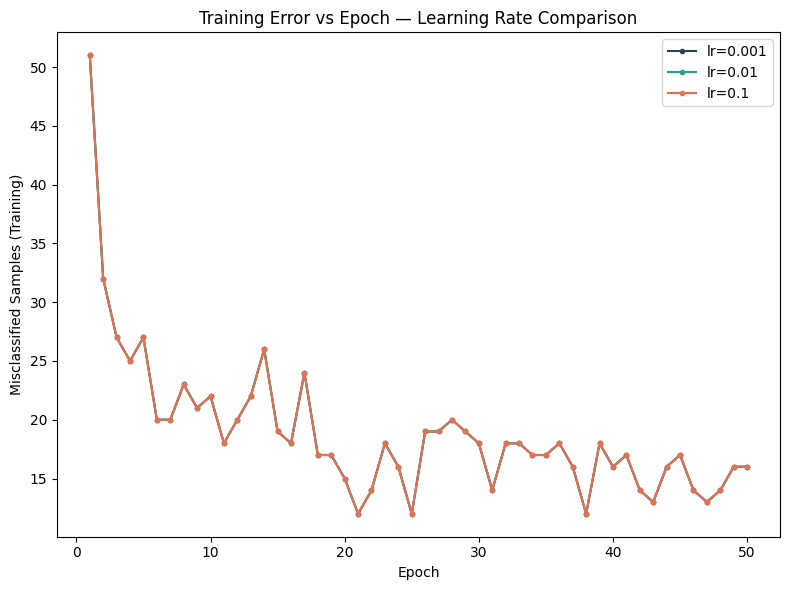

In [ ]:
# ---- Run the SAME train_perceptron from Task 5, once per learning rate ----
learning_rates = [0.001, 0.01, 0.1]
results = {}

for lr in learning_rates:
    weights, bias, history = train_perceptron(X_train_scaled, y_train, lr=lr, epochs=50)
    y_pred_test = np.array([predict(x, weights, bias) for x in X_test_scaled])

    misclassified_counts = [h[1] for h in history]

    results[lr] = {
        'misclassified_counts': misclassified_counts,
        'weights': weights,
        'bias': bias,
        'acc': accuracy_score(y_test, y_pred_test),
        'prec': precision_score(y_test, y_pred_test),
        'rec': recall_score(y_test, y_pred_test),
        'f1': f1_score(y_test, y_pred_test)
    }
    print(f"lr={lr:<6} | epochs_run={len(history):3d} | "
          f"Acc={results[lr]['acc']:.4f} Prec={results[lr]['prec']:.4f} "
          f"Rec={results[lr]['rec']:.4f} F1={results[lr]['f1']:.4f}")


plt.figure(figsize=(8, 6))
colors = {0.001: '#264653', 0.01: '#2a9d8f', 0.1: '#e76f51'}
for lr in learning_rates:
    counts = results[lr]['misclassified_counts']
    plt.plot(range(1, len(counts) + 1), counts, label=f'lr={lr}',
              color=colors[lr], marker='o', markersize=3)

plt.xlabel('Epoch')
plt.ylabel('Misclassified Samples (Training)')
plt.title('Training Error vs Epoch — Learning Rate Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('lr_comparison.eps', dpi=600)
plt.show()

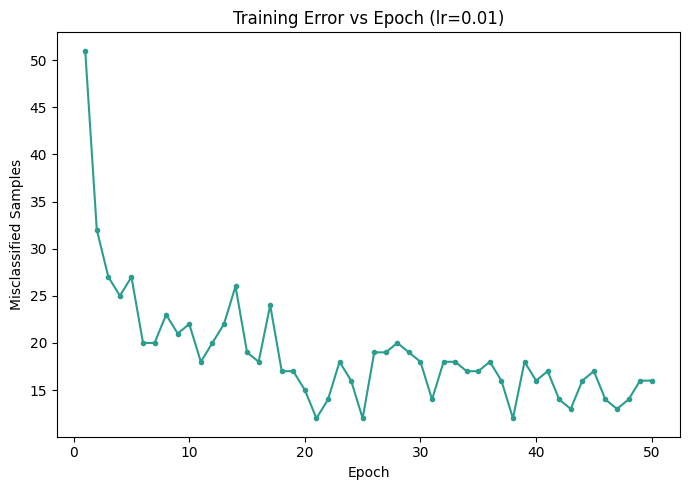

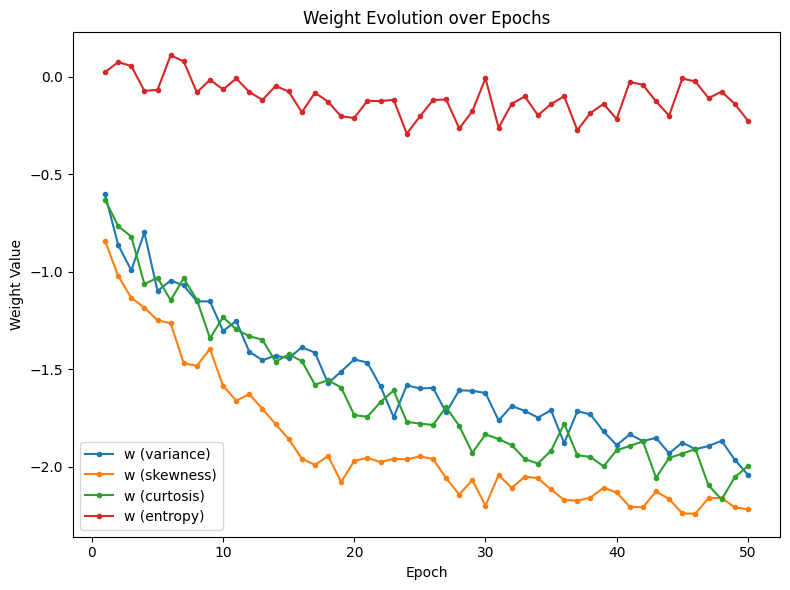

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Extract what we need from the existing history
epochs_list = [h[0] for h in history]
misclassified_list = [h[1] for h in history]
weights_list = np.array([h[2] for h in history])   # shape (n_epochs, 4)
bias_list = [h[3] for h in history]
feature_names = ['variance', 'skewness', 'curtosis', 'entropy']

# ---------- 1. Training Error vs Epoch ----------
plt.figure(figsize=(7, 5))
plt.plot(epochs_list, misclassified_list, color='#2a9d8f', marker='o', markersize=3)
plt.xlabel('Epoch'); plt.ylabel('Misclassified Samples')
plt.title('Training Error vs Epoch (lr=0.01)')
plt.tight_layout(); plt.savefig('training_error_vs_epoch.eps', dpi=600); plt.show()

# ---------- 2. Weight Evolution ----------
plt.figure(figsize=(8, 6))
for i, fname in enumerate(feature_names):
    plt.plot(epochs_list, weights_list[:, i], marker='o', markersize=3, label=f'w ({fname})')
plt.xlabel('Epoch'); plt.ylabel('Weight Value')
plt.title('Weight Evolution over Epochs')
plt.legend(); plt.tight_layout(); plt.savefig('weight_evolution.eps', dpi=600); plt.show()

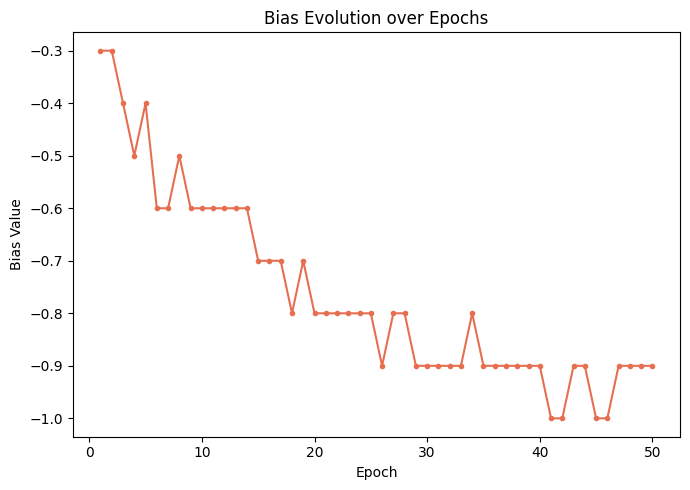

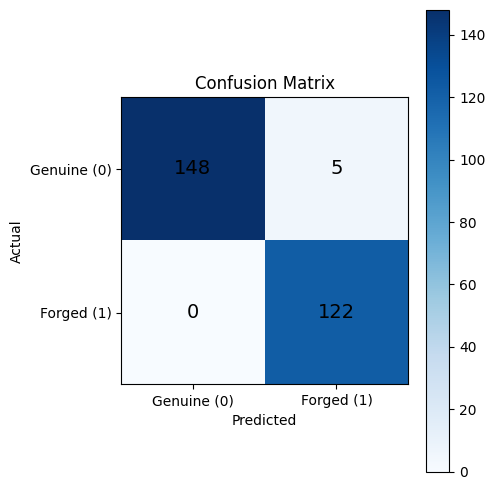

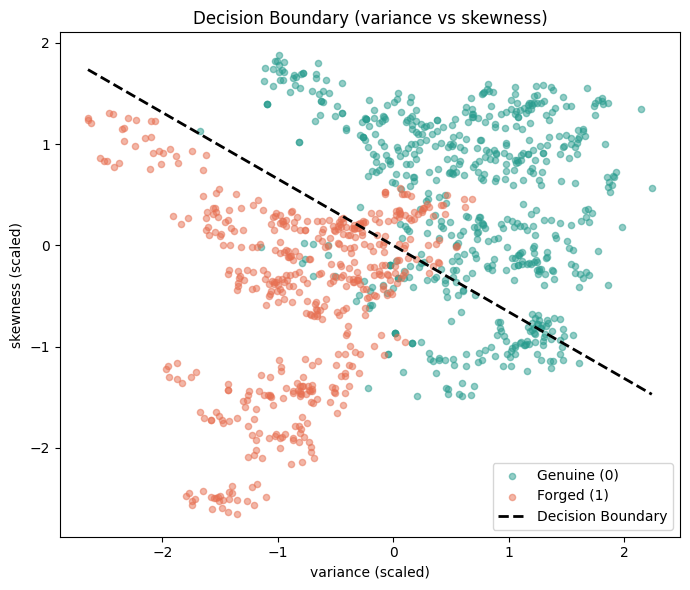

In [ ]:
# ---------- 3. Bias Evolution ----------
plt.figure(figsize=(7, 5))
plt.plot(epochs_list, bias_list, color='#e76f51', marker='o', markersize=3)
plt.xlabel('Epoch'); plt.ylabel('Bias Value')
plt.title('Bias Evolution over Epochs')
plt.tight_layout(); plt.savefig('bias_evolution.eps', dpi=600); plt.show()

# ---------- 4. Confusion Matrix Plot ----------
y_pred_test = np.array([predict(x, weights, bias) for x in X_test_scaled])
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(5, 5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks([0, 1], ['Genuine (0)', 'Forged (1)'])
plt.yticks([0, 1], ['Genuine (0)', 'Forged (1)'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black', fontsize=14)
plt.colorbar(); plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150); plt.show()


X2 = data[['variance', 'skewness']].values
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)
mean2, std2 = X2_train.mean(axis=0), X2_train.std(axis=0)
X2_train_scaled = (X2_train - mean2) / std2

w2, b2, _ = train_perceptron(X2_train_scaled, y2_train, lr=0.01, epochs=50)

plt.figure(figsize=(7, 6))
genuine_mask = y2_train == 0
forged_mask = y2_train == 1
plt.scatter(X2_train_scaled[genuine_mask, 0], X2_train_scaled[genuine_mask, 1],
             alpha=0.5, label='Genuine (0)', color='#2a9d8f', s=20)
plt.scatter(X2_train_scaled[forged_mask, 0], X2_train_scaled[forged_mask, 1],
             alpha=0.5, label='Forged (1)', color='#e76f51', s=20)

x_vals = np.linspace(X2_train_scaled[:, 0].min(), X2_train_scaled[:, 0].max(), 100)
y_vals = -(w2[0] * x_vals + b2) / w2[1]
plt.plot(x_vals, y_vals, 'k--', linewidth=2, label='Decision Boundary')

plt.xlabel('variance (scaled)'); plt.ylabel('skewness (scaled)')
plt.title('Decision Boundary (variance vs skewness)')
plt.legend(); plt.tight_layout(); plt.savefig('decision_boundary.eps', dpi=600); plt.show()